# Notebook 01 — Baseline de colorización (OpenCV-DNN, CIE-Lab)

Objetivo: flujo *mínimo y reproducible* que (1) carga el modelo Caffe de Zhang, (2) convierte a CIE-Lab, extrae **L**, centra **L−50** y reduce a **224×224**, (3) infiere **a,b**, hace *upsampling* y reconstruye **Lab→BGR**, (4) muestra antes/después y guarda en `../data/results/`.

Nota: este notebook asume que se ejecuta desde la carpeta `notebooks/` del repo.


In [5]:
from pathlib import Path
import cv2 as cv
import numpy as np

BASE = Path('..').resolve()
MODELS = BASE / 'models'

DATA_RAW = (BASE / 'imgs')
DATA_RES = (BASE / 'imgs_out')

PROTOTXT   = MODELS / 'colorization_deploy_v2.prototxt'
CAFFEMODEL = MODELS / 'colorization_release_v2.caffemodel'
PTS_NPY    = MODELS / 'pts_in_hull.npy'

print('BASE   =', BASE)
print('RAW    =', DATA_RAW)
print('RES    =', DATA_RES)

BASE   = C:\Users\adria\OneDrive\Escritorio\UNI\PID\Trabajo\PID_colorization
RAW    = C:\Users\adria\OneDrive\Escritorio\UNI\PID\Trabajo\PID_colorization\imgs
RES    = C:\Users\adria\OneDrive\Escritorio\UNI\PID\Trabajo\PID_colorization\imgs_out


## Función `colorize_bgr`
- Carga la red Caffe y **inyecta** los centros de color (`pts_in_hull.npy`) en `class8_ab` y el re-peso en `conv8_313_rh`.
- **Preproceso**: BGR→RGB→Lab con normalización en [0,1]; **L−50** y **224×224** como entrada.
- **Postproceso**: *upsampling* de **a,b**, reconstrucción **Lab→RGB→BGR** y retorno como `uint8`.

In [6]:
def colorize_bgr(img_bgr):
    # Cargar red
    net = cv.dnn.readNetFromCaffe(str(PROTOTXT), str(CAFFEMODEL))

    # Inyección de centros ab (313x2) + re-peso
    pts = np.load(str(PTS_NPY)).transpose().reshape(2, 313, 1, 1).astype('float32')
    net.getLayer(net.getLayerId('class8_ab')).blobs    = [pts]
    net.getLayer(net.getLayerId('conv8_313_rh')).blobs = [np.full((1,313), 2.606, 'float32')]

    # Preproceso
    img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB).astype('float32') / 255.0
    img_lab = cv.cvtColor(img_rgb, cv.COLOR_RGB2Lab)
    L = img_lab[:, :, 0]

    L_rs = cv.resize(L, (224, 224))
    L_rs -= 50
    blob = cv.dnn.blobFromImage(L_rs)

    # Forward
    net.setInput(blob)
    ab = net.forward()[0].transpose(1, 2, 0)           # H'×W'×2
    ab_up = cv.resize(ab, (img_bgr.shape[1], img_bgr.shape[0]))

    # Reconstrucción
    Lab_out = np.concatenate([L[:, :, None], ab_up], axis=2).astype('float32')
    out_rgb = cv.cvtColor(Lab_out, cv.COLOR_Lab2RGB)
    out_rgb = (np.clip(out_rgb, 0, 1) * 255.0).astype('uint8')
    out_bgr = cv.cvtColor(out_rgb, cv.COLOR_RGB2BGR)
    return out_bgr

## Ejecutar con una imagen de prueba
Coloca `../data/raw/ejemplo.jpg`. La salida se guardará en `../data/results/ejemplo_color.png`.

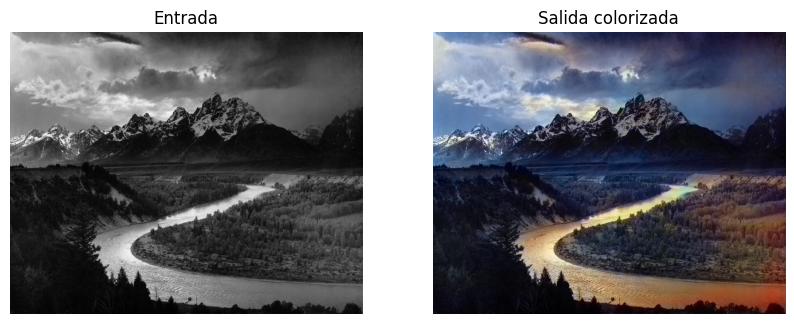

Guardado -> C:\Users\adria\OneDrive\Escritorio\UNI\PID\Trabajo\PID_colorization\imgs_out\ansel_adams_color.png


In [9]:
# Cargar imagen de prueba
img_path = DATA_RAW / 'ansel_adams.jpg'   # cambia si usas otro nombre
img_bgr = cv.imread(str(img_path))
assert img_bgr is not None, f'No se encontró la imagen: {img_path}'

# Inferencia
out_bgr = colorize_bgr(img_bgr)

# Guardar y visualizar
out_path = DATA_RES / 'ansel_adams_color.png'
cv.imwrite(str(out_path), out_bgr)

fig, ax = plt.subplots(1, 2, figsize=(10,4))
ax[0].imshow(cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)); ax[0].set_title('Entrada'); ax[0].axis('off')
ax[1].imshow(cv.cvtColor(out_bgr, cv.COLOR_BGR2RGB)); ax[1].set_title('Salida colorizada'); ax[1].axis('off')
plt.show()

print('Guardado ->', out_path)

In [11]:
for p in DATA_RAW.glob('*'):
    img = cv.imread(str(p))
    if img is None: 
        continue
    out = colorize_bgr(img)
    out_path = DATA_RES / f"{p.stem}_color.png"
    cv.imwrite(str(out_path), out)
out_path

WindowsPath('C:/Users/adria/OneDrive/Escritorio/UNI/PID/Trabajo/PID_colorization/imgs_out/ILSVRC2012_val_00046834_color.png')